In [1]:
# Chapter 4 : Training Models
# Linear Regression
# y_pred = m0 + m1x1 + m2x2 + ... + mnxn
# m0 is bias term or intercept.
# m1,m2,... are feature weights.
# y_pred = theta.x where, theta is model's parameter vector and x is instance feature vector.
# In ML, we write y_pred = (theta.T)x
# We minimize the MSE intead of RMSE cuz it's easier.
# We use a loss func that is easy to minimize for that model, like for classifiers we use log-loss but evaluate using precision/recall.
# MSE = sum((y-y_pred)^2)/m

In [82]:
# The Normal Equation
# theta = (((X.T)X)^-1)(X.T)Y
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=100,n_features=1,n_targets=1,noise=30)

In [83]:
x[:5]

array([[-0.34832271],
       [-0.73923718],
       [ 0.62884551],
       [-2.37855188],
       [ 0.66042024]])

In [84]:
y[:5]

array([ -53.49497728, -104.77126608,   61.93247994, -275.02839885,
         88.09814256])

In [85]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

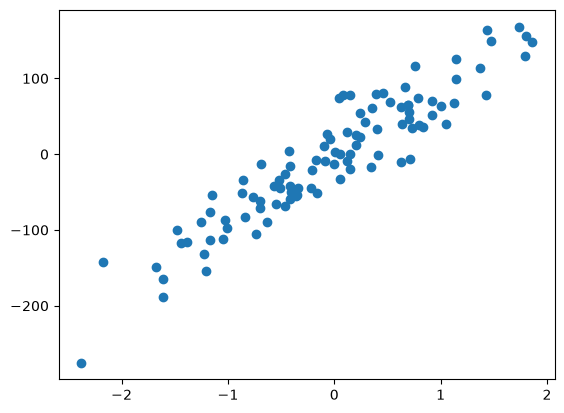

In [86]:
import matplotlib.pyplot as plt
plt.scatter(x=x,y=y)

In [87]:
# finding optimal weights:
from sklearn.preprocessing import add_dummy_feature
import numpy as np
x_b = add_dummy_feature(x_train) # adds x0 =1 to each instance
theta = np.linalg.inv(x_b.T@x_b)@x_b.T@y_train

In [88]:
theta

array([ 1.60984599, 86.52875388])

In [89]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[86.53]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.61
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.14]


In [90]:
lr.intercept_

np.float64(1.6098459928987188)

In [91]:
lr.coef_

array([86.52875388])

In [92]:
from sklearn.metrics import r2_score
r2_score(y_test,lr.predict(x_test))

0.8298245037745361

In [93]:
r2_score(y_test,add_dummy_feature(x_test).dot(theta))

0.829824503774536

In [94]:
y_test

array([  11.81134173,  -18.93601875,   -8.41940354,   32.60071765,
         -9.90530332, -153.70842511,  156.3987714 ,  -97.03207043,
        -51.43807419,  -53.49497728,  -33.1075755 ,  116.3348493 ,
         -5.93203794, -164.16210874,  -25.68035777,   88.09814256,
         -0.57081112,  130.10305832,   39.76694147,  -20.54811026])

In [95]:
lr.predict(x_test)

array([  19.50969516,   14.59223885,   12.30673054,   36.50614961,
         56.10078402, -102.94924884,  157.8853771 ,  -85.54556739,
        -73.26115263,  -28.53008396,    6.31565006,   67.35839711,
         63.08992145, -137.58930765,  -38.84166354,   58.75518619,
         37.36985434,  156.89745326,   56.67041993,  -16.22966024])

<Axes: >

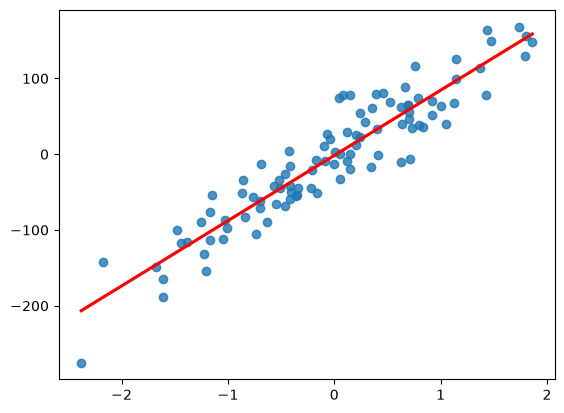

In [103]:
import seaborn as sns
sns.regplot(x=x,y=y,ci=None,line_kws={'color':'red'})

In [111]:
# sklearn's linear regression is based on scipy.linalg.lstsq() 
theta_best_svd, residuals, rank, s =np.linalg.lstsq(x_b,y_train,rcond=1e-6)

In [112]:
s

array([9.0544516 , 8.03978922])

In [113]:
rank

np.int32(2)

In [114]:
residuals

array([67687.81293771])

In [115]:
theta_best_svd

array([ 1.60984599, 86.52875388])